In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("olist_order_items_dataset_cle.csv")
df.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,19-09-2017 09:45,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,03-05-2017 11:05,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,18-01-2018 14:48,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,15-08-2018 10:10,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,13-02-2017 13:57,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,23-05-2017 03:55,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,14-12-2017 12:10,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,10-07-2018 12:30,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,26-03-2018 18:31,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,06-07-2018 14:10,53.99,11.40


In [51]:
df.dtypes

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
shipping_year                   int32
shipping_month                 object
total_value                   float64
dtype: object

In [5]:
df.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
 price                 0
 freight_value         0
dtype: int64

In [50]:
df[df["total_value"].isna()]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,shipping_year,shipping_month,total_value


In [45]:
df["freight_value"] = df["freight_value"].astype(float)
df[df["freight_value"].isna()]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,shipping_year,shipping_month
114,00404fa7a687c8c44ca69d42695aae73,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-15 04:31:00,99.9,NaN,2018,May
258,00a870c6c06346e85335524935c600c0,1,aca2eb7d00ea1a7b8ebd4e68314663af,955fee9216a65b617aa5c0531780ce60,2018-05-14 00:14:00,69.9,NaN,2018,May
483,011c899816ea29773525bd3322dbb6aa,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-07 05:30:00,99.9,NaN,2018,May
508,012b3f6ab7776a8ab3443a4ad7bef2e6,1,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:00,53.9,NaN,2018,May
509,012b3f6ab7776a8ab3443a4ad7bef2e6,2,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:00,53.9,NaN,2018,May
...,...,...,...,...,...,...,...,...,...
111094,fc698f330ec7fb74859071cc6cb29772,1,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-04-25 02:31:00,53.9,NaN,2018,April
111497,fd4907109f6bac23f07064af84bec02d,1,7a10781637204d8d10485c71a6108a2e,4869f7a5dfa277a7dca6462dcf3b52b2,2018-04-30 11:31:00,219.0,NaN,2018,April
111649,fd95e4b85ebbb81853d4a6be3d61432b,1,53b36df67ebb7c41585e8d54d6772e08,4869f7a5dfa277a7dca6462dcf3b52b2,2018-05-04 11:10:00,106.9,NaN,2018,May
112182,fee19a0dc7358b6962a611cecf6a37b4,1,f1c7f353075ce59d8a6f3cf58f419c9c,37be5a7c751166fbc5f8ccba4119e043,2017-09-07 22:06:00,195.0,NaN,2017,September


In [44]:
df["freight_value"] = (
    df["freight_value"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["freight_value"] = pd.to_numeric(
    df["freight_value"],
    errors="coerce"
)


In [ ]:
df.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,19-09-2017 09:45,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,03-05-2017 11:05,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,18-01-2018 14:48,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,15-08-2018 10:10,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,13-02-2017 13:57,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,23-05-2017 03:55,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,14-12-2017 12:10,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,10-07-2018 12:30,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,26-03-2018 18:31,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,06-07-2018 14:10,53.99,11.40


In [ ]:
#df=df.drop(columns = [" freight_value "])


In [ ]:
df.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,shipping_year,shipping_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:00,58.90,13.29,2017,September
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:00,239.90,19.93,2017,May
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:00,199.00,17.87,2018,January
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:00,12.99,12.79,2018,August
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:00,199.90,18.14,2017,February
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:00,21.90,12.69,2017,May
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:00,19.90,11.85,2017,December
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:00,810.00,70.75,2018,July
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:00,145.95,11.65,2018,March
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:00,53.99,11.40,2018,July


In [ ]:
df=df.rename(columns={" price ":"price"})

In [55]:
df.dtypes

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
shipping_year                   int32
shipping_month                 object
total_value                   float64
dtype: object

In [8]:
date_columns = [
    "shipping_limit_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        format = "%d-%m-%Y %H:%M",
        errors="coerce"
    )

In [9]:
df["shipping_year"]=df["shipping_limit_date"].dt.year 

In [10]:
df["shipping_month"]=df["shipping_limit_date"].dt.month_name()

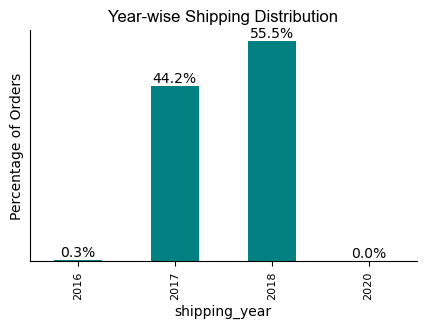

In [11]:
ax = (
    df["shipping_year"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
    .plot(
        kind="bar",
        figsize=(5,3),
        color="teal",
        fontsize=8
    )
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_title(
    "Year-wise Shipping Distribution",
    fontsize=12,
    fontfamily="Arial"
)

ax.set_ylabel("Percentage of Orders")
ax.set_yticks([])

plt.show()

55% of the shipping was in the year 2018

In [12]:
df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', ' price ', ' freight_value ', 'shipping_year',
       'shipping_month'],
      dtype='object')

In [13]:
df["shipping_month"].value_counts()

shipping_month
August       13857
May          12915
March        11510
July         10788
June         10698
April        10003
February      9243
January       8173
December      7727
November      7355
October       5554
September     4827
Name: count, dtype: int64

august was the month with more shipping and may following closely

In [49]:
df.groupby("seller_id")["total_value"].sum().sort_values(ascending=False).head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    249640.70
7c67e1448b00f6e969d365cea6b010ab    239536.44
53243585a1d6dc2643021fd1853d8905    235856.68
4a3ca9315b744ce9f8e9374361493884    235539.96
fa1c13f2614d7b5c4749cbc52fecda94    204084.73
da8622b14eb17ae2831f4ac5b9dab84a    185192.32
7e93a43ef30c4f03f38b393420bc753a    182754.05
1025f0e2d44d7041d6cf58b6550e0bfa    172860.69
7a67c85e85bb2ce8582c35f2203ad736    162648.38
955fee9216a65b617aa5c0531780ce60    160602.68
Name: total_value, dtype: float64

top 10 sellers by total_value 

In [1]:
df["total_value"] = df["price"] + df["freight_value"].fillna(0)

NameError: name 'df' is not defined

In [35]:
df[df["freight_value"].isna()][
    ["order_id", "price", "product_id", "seller_id"]
].head(20)

,order_id,price,product_id,seller_id


In [33]:
df["freight_value"].isna().sum()
df["price"].isna().sum()

0

In [18]:
df["seller_id"].value_counts().head(10)

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
Name: count, dtype: int64

top 10 sellers by products sold

In [32]:
df.groupby("seller_id")["price"].mean().sort_values(ascending=False)

seller_id
80ceebb4ee9b31afb6c6a916a574a1e2    6729.000000
ee27a8f15b1dded4d213a468ba4eb391    6499.000000
585175ec331ea177fa47199e39a6170a    3549.000000
abe021b01ba992245271b9aa422032df    3360.000000
a00824eb9093d40e589b940ec45c4eb0    3133.323333
                                       ...     
1fa2d3def6adfa70e58c276bb64fe5bb       6.900000
77128dec4bec4878c37ab7d6169d6f26       6.500000
6c9875b2f94ba781186f0c1aed8d1687       6.250000
3d62f86afa7c73be2628a3be1423f5a0       6.000000
cf6f6bc4df3999b9c6440f124fb2f687       3.500000
Name: price, Length: 3095, dtype: float64

Average price by sellers 

In [31]:
seller_analysis = df.groupby("seller_id").agg(
    avg_price=("price","mean"),
    total_products=("product_id","count")
)

seller_analysis[
    seller_analysis["total_products"] >= 50
].sort_values(
    by="avg_price",
    ascending=False
)

,avg_price,total_products
seller_id,,
e882b2a25a10b9c057cc49695f222c19,880.302414,58
17f51e7198701186712e53a39c564617,787.196721,61
966cb4760537b1404caedd472cc610a5,683.814000,75
04308b1ee57b6625f47df1d56f00eedf,639.687234,94
834f3294fba9f932f56edc879193f925,604.659091,66
...,...,...
138dbe45fc62f1e244378131a6801526,19.406207,58
92eb0f42c21942b6552362b9b114707d,17.941452,365
8b321bb669392f5163d04c59e235e066,17.225629,1018


In [27]:
df=df.rename(columns={" price ":"price"})
df = df.rename(columns={" freight_value ":"freight_value"})
df=df.rename(columns={" price ":"price"})


In [21]:
df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', ' price ', ' freight_value ', 'shipping_year',
       'shipping_month'],
      dtype='object')

In [62]:
df.to_csv("olist_orders_items_cleaned.csv", index=False)

<Axes: xlabel='price', ylabel='freight_value'>

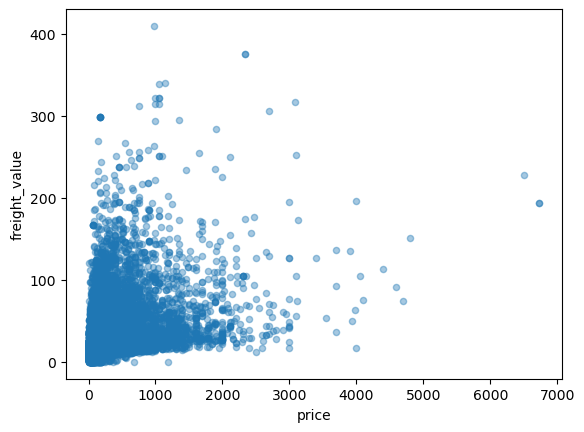

In [60]:
df.plot.scatter(
    x="price",
    y="freight_value",
    alpha=0.4
)

In [ ]:
df[["price", "freight_value"]].corr()

,price,freight_value
price,1.000000,0.414882
freight_value,0.414882,1.000000


In [ ]:
df["price_range"] = pd.cut(
    df["price"],
    bins=[0,50,100,200,500,1000,7000],
    labels=[
        "0-50",
        "50-100",
        "100-200",
        "200-500",
        "500-1000",
        "1000+"
    ]
)

df.groupby("price_range")["freight_value"].mean()

C:\Users\Mohammed mustafa\AppData\Local\Temp\ipykernel_9376\4239839701.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("price_range")["freight_value"].mean()


price_range
0-50        14.765093
50-100      18.030541
100-200     23.199417
200-500     30.086675
500-1000    43.074682
1000+       60.148578
Name: freight_value, dtype: float64

average freight value by price range 

In [ ]:
df.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
price_range            0
dtype: int64

In [ ]:
df[df["price_range"].isna()]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,price_range


In [ ]:
df.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,price_range
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,19-09-2017 09:45,58.90,13.29,50-100
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,03-05-2017 11:05,239.90,19.93,200-500
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,18-01-2018 14:48,199.00,17.87,100-200
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,15-08-2018 10:10,12.99,12.79,0-50
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,13-02-2017 13:57,199.90,18.14,100-200
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,23-05-2017 03:55,21.90,12.69,0-50
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,14-12-2017 12:10,19.90,11.85,0-50
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,10-07-2018 12:30,810.00,70.75,500-1000
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,26-03-2018 18:31,145.95,11.65,100-200
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,06-07-2018 14:10,53.99,11.40,50-100


In [52]:
df.dropna(subset=["freight_value"], inplace=True)

In [29]:
df["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [28]:
df["price"].quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99])

0.25     39.90
0.50     74.99
0.75    134.90
0.90    229.80
0.95    349.90
0.99    890.00
Name: price, dtype: float64

In [53]:
df["shipping_year"].unique()

array([2017, 2018, 2016, 2020])

In [56]:
df["shipping_month"].unique()

array(['September', 'May', 'January', 'August', 'February', 'December',
       'July', 'March', 'November', 'June', 'April', 'October'],
      dtype=object)

In [59]:
df[df["order_id"]=="Blank"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,shipping_year,shipping_month,total_value
